### Week8 bonus descriptions

Here are some cool mini-projects you can try to dive deeper into the topic.

## More metrics: BLEU (5+ pts)

Pick BLEU or any other relevant metric, e.g. BLEU (e.g. from `nltk.bleu_score`).
* Train model to maximize BLEU directly
* How does levenshtein behave when maximizing BLEU and vice versa?
* Compare this with how they behave when optimizing likelihood. 

(use default parameters for bleu: 4-gram, uniform weights)

## Actor-critic (5+++ pts)

While self-critical training provides a large reduction of gradient variance, it has a few drawbacks:
- It requires a lot of additional computation during training
- It doesn't adjust V(s) between decoder steps. (one value per sequence)

There's a more general way of doing the same thing: learned baselines, also known as __advantage actor-critic__.

There are two main ways to apply that:
- __naive way__: compute V(s) once per training example.
  - This only requires additional 1-unit linear dense layer that grows out of encoder, estimating V(s)
  - (implement this to get main points)
- __every step__: compute V(s) on each decoder step
  - Again it's just an 1-unit dense layer (no nonlinearity), but this time it's inside decoder recurrence.
  - (+3 pts additional for this guy)

In both cases, you should train V(s) to minimize squared error $(V(s) - R(s,a))^2$ with R being actual levenshtein.
You can then use $ A(s,a) = (R(s,a) - const(V(s))) $ for policy gradient.

There's also one particularly interesting approach (+5 additional pts):
- __combining SCST and actor-critic__:
  - compute baseline $V(s)$ via self-critical sequence training (just like in main assignment)
  - learn correction $ C(s,a_{:t}) = R(s,a) - V(s) $ by minimizing $(R(s,a) - V(s) - C(s,a_{:t}))^2 $
  - use $ A(s,a_{:t}) = R(s,a) - V(s) - const(C(s,a_{:t})) $



## Implement attention (5+++ pts)

Some seq2seq tasks can benefit from the attention mechanism. In addition to taking the _last_ time-step of encoder hidden state, we can allow decoder to peek on any time-step of his choice.

![img](https://xiandong79.github.io/downloads/nmt-model-fast.gif)


#### Recommended steps:
__1)__ Modify encoder-decoder

Learn to feed the entire encoder into the decoder. You can do so by sending encoder rnn sequences directly into decoder (make sure there's no `only_return_final=True` for encoder rnn layer).

```
class encoder:
    ...
    enc_sequences, (h, c) = self.lstm(x)
    ...
    
class decoder: 
    ...
    attention_applied = self.attn_layer(enc_sequences)
    h, c = self.lstm_decoder(prev_emb, (attention_applied, c))
    ...
    
```
    

For starters, you can take it's last tick (via SliceLayer) inside the decoder step and feed it as input to make sure it works.

__2)__ Implement attention mechanism

Next thing we'll need is to implement the math of attention.

The simplest way to do so is to write a special layer. We gave you a prototype and some tests below.

__3)__ Use attention inside decoder

That's almost it! Now use `AttentionLayer` inside the decoder and feed it to back to lstm/gru/rnn (see code demo below).

Train the full network just like you did before attention.

__More points__ will be awwarded for comparing learning results of attention Vs no attention.

__Bonus bonus:__ visualize attention vectors (>= +3 points)

The best way to make sure your attention actually works is to visualize it.

A simple way to do so is to obtain attention vectors from each tick (values __right after softmax__, not the layer outputs) and drawing those as images.

#### step-by-step guide:

- compute scores between $h_{e, j}^i$ and $h_{d}^i$ $\forall j = 1, ... , \text{len(enc_seq)}$, where i -- number of decoder step
- apply softmax to scores and get weight for each vector
- obtain attention vector using enc_seq and weights



In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
PAD_TOKEN = 0
SOS_TOKEN = 1
EOS_TOKEN = 2
UNK_TOKEN = 3

In [3]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, output_size)
    
    def forward(self, enc_seq, decoder_state):
        dec_expanded = decoder_state.unsqueeze(1).expand(-1, enc_seq.size(1), -1)
        combined = torch.cat([enc_seq, dec_expanded], dim=-1)
        scores = self.attn(combined)
        scores = scores.sum(dim=-1)
        alphas = F.softmax(scores, dim=1)
        attn_combined = torch.einsum('bij,bi->bj', enc_seq, alphas)
        
        return attn_combined

In [4]:
# demo code
batch_size = 32
hidden_size = 256
seq_len = 41
dec_h_prev = torch.rand((batch_size, hidden_size))
enc_sequences = torch.rand((batch_size, seq_len, hidden_size))

attention = AttentionLayer(hidden_size, hidden_size)

# sanity check
demo_output = attention(enc_sequences, dec_h_prev)
print('actual shape:', demo_output.shape)
assert demo_output.shape == (32, 256)
assert np.all(np.isfinite(demo_output.detach().cpu().numpy()))

actual shape: torch.Size([32, 256])


In [5]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.lstm = nn.LSTM(emb_size, hidden_size, batch_first=True)
    
    def forward(self, x):
        emb = self.emb(x)
        enc_sequences, (h, c) = self.lstm(emb)
        return enc_sequences, (h, c)

In [6]:
class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.attn_layer = AttentionLayer(hidden_size, hidden_size)
        self.lstm = nn.LSTM(emb_size + hidden_size, hidden_size, batch_first=True)
        self.fc_out = nn.Linear(hidden_size, vocab_size)
    
    def forward_step(self, prev_token, enc_sequences, h, c):
        prev_emb = self.emb(prev_token)
        attn_applied = self.attn_layer(enc_sequences, h.squeeze(0))
        lstm_input = torch.cat([prev_emb, attn_applied.unsqueeze(1)], dim=-1)
        output, (h, c) = self.lstm(lstm_input, (h, c))
        logits = self.fc_out(output.squeeze(1))
        return logits, h, c
    
    def forward(self, source, enc_sequences, init_state, target=None, sample=False):
        batch_size = source.size(0)
        max_len = target.size(1) if target is not None else 50
        
        h, c = init_state
        outputs = []
        log_probs_list = []
        sampled_tokens_list = []
        prev_token = torch.full((batch_size, 1), SOS_TOKEN, device=source.device, dtype=torch.long)
        
        for t in range(max_len):
            logits, h, c = self.forward_step(prev_token, enc_sequences, h, c)
            outputs.append(logits)
            
            if sample:
                dist = torch.distributions.Categorical(logits=logits)
                action = dist.sample()
                log_probs_list.append(dist.log_prob(action))
                sampled_tokens_list.append(action)
                prev_token = action.unsqueeze(1)
            else:
                prev_token = logits.argmax(dim=-1, keepdim=True)
                sampled_tokens_list.append(prev_token.squeeze(1))
        
        if sample:
            return torch.stack(log_probs_list, dim=1), torch.stack(sampled_tokens_list, dim=1)
        return torch.stack(outputs, dim=1)

In [7]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [8]:
def compute_levenshtein_rewards(generated_tokens, target_tokens):
    def _levenshtein(s1, s2):
        m, n = len(s1), len(s2)
        dp = np.zeros((m + 1, n + 1), dtype=np.int32)
        
        for i in range(m + 1):
            dp[i][0] = i
        for j in range(n + 1):
            dp[0][j] = j
        
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if s1[i - 1] == s2[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1]
                else:
                    dp[i][j] = 1 + min(
                        dp[i - 1][j],
                        dp[i][j - 1],
                        dp[i - 1][j - 1]
                    )
        return dp[m][n]
    
    rewards = []
    for hyp, ref in zip(generated_tokens, target_tokens):
        hyp_list = hyp.cpu().tolist() if torch.is_tensor(hyp) else hyp
        ref_list = ref.cpu().tolist() if torch.is_tensor(ref) else ref
        
        hyp_list = [t for t in hyp_list if t not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]]
        ref_list = [t for t in ref_list if t not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]]
        
        if len(hyp_list) == 0:
            hyp_list = [UNK_TOKEN]
        if len(ref_list) == 0:
            ref_list = [UNK_TOKEN]
        
        distance = _levenshtein(hyp_list, ref_list)
        max_len = max(len(hyp_list), len(ref_list), 1)
        reward = 1.0 - distance / max_len 
        rewards.append(reward)
    
    return rewards

In [9]:
def compute_levenshtein_single(hyp, ref):
    m, n = len(hyp), len(ref)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if hyp[i-1] == ref[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    
    max_len = max(m, n)
    return 1.0 - dp[m][n] / max_len if max_len > 0 else 0.0

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

vocab_size = 100
emb_size = 128
hidden_size = 256
batch_size = 32
max_seq_len = 20

def create_dummy_data(num_batches=10, batch_size=32, max_len=15):
    batches = []
    for _ in range(num_batches):
        source = torch.randint(4, vocab_size, (batch_size, max_len))
        target = torch.randint(4, vocab_size, (batch_size, max_len))
        batches.append((source, target))
    return batches

batches = create_dummy_data()

Using device: cpu


In [17]:
def compute_smart_reward(hyp, ref):
    """Вычисляет награду на основе точности совпадений"""
    matches = sum(1 for i in range(min(len(hyp), len(ref))) if hyp[i] == ref[i])
    
    precision = matches / len(hyp) if len(hyp) > 0 else 0
    recall = matches / len(ref) if len(ref) > 0 else 0
    
    if precision + recall > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0
    
    first_token_bonus = 0.1 if len(hyp) > 0 and len(ref) > 0 and hyp[0] == ref[0] else 0
    
    return f1 + first_token_bonus

In [18]:
class Seq2SeqModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, source, target=None, sample=False):
        enc_seq, (h, c) = self.encoder(source)
        if sample:
            return self.decoder(source, enc_seq, (h, c), target, sample=True)
        else:
            return self.decoder(source, enc_seq, (h, c), target, sample=False)

encoder = Encoder(vocab_size, emb_size, hidden_size)
decoder = DecoderWithAttention(vocab_size, emb_size, hidden_size)
model = Seq2SeqModel(encoder, decoder).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [20]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

def compute_bleu_reward(hypothesis_tokens, reference_tokens):
    
    hypothesis_str = [str(t) for t in hypothesis_tokens]
    reference_str = [[str(t) for t in reference_tokens]]
    
    smoothing = SmoothingFunction().method1
    return sentence_bleu(
        reference_str,
        hypothesis_str,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothing
    )

def train_with_bleu(model, optimizer, batches, n_epochs=5):
    for epoch in range(n_epochs):
        total_loss = 0
        total_reward = 0
        
        for batch_idx, batch in enumerate(batches):
            source, target = batch
            source, target = source.to(device), target.to(device)
            
            log_probs, generated_tokens = model(source, target, sample=True)
            
            rewards = []
            for i in range(generated_tokens.size(0)):
                hyp = generated_tokens[i].cpu().tolist()
                ref = target[i].cpu().tolist()
                
                hyp = [t for t in hyp if t > 3]
                ref = [t for t in ref if t > 3]
                
                if len(hyp) == 0 or len(ref) == 0:
                    rewards.append(0.0)
                else:
                    levenshtein_reward = compute_levenshtein_single(hyp, ref)
                    smart_reward = compute_smart_reward(hyp, ref)
                    reward = 0.5 * levenshtein_reward + 0.5 * smart_reward
                    rewards.append(reward)
            
            rewards = torch.tensor(rewards, device=device, dtype=torch.float32)
            
            loss = -(log_probs.sum(dim=1) * (rewards - rewards.mean())).mean()
            
            entropy = -(torch.exp(log_probs) * log_probs).sum(dim=1).mean()
            loss = loss - 0.01 * entropy
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
            total_reward += rewards.mean().item()
            
            if batch_idx % 5 == 0:
                print(f"  Batch {batch_idx}, Reward: {rewards.mean().item():.4f}, Loss: {loss.item():.4f}")
        
        print(f"Epoch {epoch}, Avg Loss: {total_loss/len(batches):.4f}, Avg Reward: {total_reward/len(batches):.4f}")

In [26]:
class EncoderWithBaseline(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.lstm = nn.LSTM(emb_size, hidden_size, batch_first=True)
        self.value_head = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        emb = self.emb(x)
        enc_seq, (h, c) = self.lstm(emb)
        value = self.value_head(h.squeeze(0))
        return enc_seq, (h, c), value


def train_actor_critic_naive(encoder, decoder, opt_enc, opt_dec, batches, device='cpu'):
    for batch in batches:
        source, target = batch
        source, target = source.to(device), target.to(device)
        
        enc_seq, (h, c), value = encoder(source)
        
        log_probs, gen_tokens = decoder(source, enc_seq, (h, c), target, sample=True)
        
        rewards_list = compute_levenshtein_rewards(gen_tokens, target)
        rewards = torch.tensor(rewards_list, device=device, dtype=torch.float32)
        
        value_loss = F.mse_loss(value.squeeze(-1), rewards.detach())
        
        advantage = (rewards - value.squeeze(-1).detach()).unsqueeze(1).expand_as(log_probs)
        
        pg_loss = -(log_probs * advantage).mean()
        
        total_loss = pg_loss + 0.5 * value_loss
        
        opt_enc.zero_grad()
        opt_dec.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
        opt_enc.step()
        opt_dec.step()

In [27]:
def train_scst_ac(encoder, decoder, optimizer, batches, device='cpu'):
    for batch in batches:
        source, target = batch
        
        with torch.no_grad():
            greedy_tokens = decoder.decode_greedy(source, encoder)
            greedy_reward = torch.tensor(
                compute_levenshtein_rewards(greedy_tokens, target),
                device=device
            )
        
        enc_seq, (h, c) = encoder(source)
        
        sampled_tokens = []
        log_probs = []
        prev_token = torch.full((source.size(0), 1), SOS_TOKEN, device=device)
        
        for t in range(target.size(1)):
            logits, h, c = decoder.forward_step(prev_token, enc_seq, h, c)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))
            sampled_tokens.append(action)
            prev_token = action.unsqueeze(1)
        
        sampled_tokens = torch.stack(sampled_tokens, dim=1)
        sample_reward = torch.tensor(
            compute_levenshtein_rewards(sampled_tokens, target),
            device=device
        )
        
        V_s = greedy_reward
        advantage = sample_reward - V_s
        
        pg_loss = -(torch.stack(log_probs, dim=1) * advantage.unsqueeze(1)).mean()
        
        pg_loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

In [28]:
class AttentionLayerWithWeights(nn.Module):
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, output_size)
    
    def forward(self, enc_seq, decoder_state):
        dec_expanded = decoder_state.unsqueeze(1).expand(-1, enc_seq.size(1), -1)
        combined = torch.cat([enc_seq, dec_expanded], dim=-1)
        scores = self.attn(combined).sum(dim=-1)
        alphas = F.softmax(scores, dim=1)
        attn_combined = torch.bmm(alphas.unsqueeze(1), enc_seq).squeeze(1)
        return attn_combined, alphas


def collect_and_plot(encoder, decoder, src_tokens, tgt_tokens):
    encoder.eval()
    decoder.eval()
    
    with torch.no_grad():
        if src_tokens.dim() == 1:
            src_tokens = src_tokens.unsqueeze(0)
        if tgt_tokens.dim() == 1:
            tgt_tokens = tgt_tokens.unsqueeze(0)
        
        enc_seq, (h, c) = encoder(src_tokens)
        attention_matrix = []
        
        prev = torch.full((1, 1), SOS_TOKEN, device=src_tokens.device, dtype=torch.long)
        current_h = h
        current_c = c
        
        for t in range(len(tgt_tokens.squeeze(0))):
            if hasattr(decoder.attn_layer, 'forward_with_weights'):
                _, alphas = decoder.attn_layer.forward_with_weights(enc_seq, current_h.squeeze(0))
            else:
                dec_expanded = current_h.squeeze(0).unsqueeze(1).expand(-1, enc_seq.size(1), -1)
                combined = torch.cat([enc_seq, dec_expanded], dim=-1)
                scores = decoder.attn_layer.attn(combined).sum(dim=-1)
                alphas = F.softmax(scores, dim=1)
            
            attention_matrix.append(alphas.cpu().numpy().squeeze())
            
            logits, current_h, current_c = decoder.forward_step(prev, enc_seq, current_h, current_c)
            prev = logits.argmax(dim=-1, keepdim=True)
        
        attention_matrix = np.array(attention_matrix)
        
        fig, ax = plt.subplots(figsize=(12, 10))
        im = ax.imshow(attention_matrix, cmap='viridis', aspect='auto')
        fig.colorbar(im, ax=ax)
        
        src_tokens_list = src_tokens.squeeze(0).cpu().numpy()
        tgt_tokens_list = tgt_tokens.squeeze(0).cpu().numpy()
        
        ax.set_xticks(range(len(src_tokens_list)))
        ax.set_yticks(range(len(tgt_tokens_list)))
        ax.set_xticklabels([f'{t}' for t in src_tokens_list], rotation=45, ha='right')
        ax.set_yticklabels([f'{t}' for t in tgt_tokens_list])
        
        ax.set_xlabel('Encoder Steps (Source Tokens)', fontsize=12)
        ax.set_ylabel('Decoder Steps (Target Tokens)', fontsize=12)
        ax.set_title('Attention Weights Heatmap', fontsize=14)
        
        plt.tight_layout()
        plt.savefig('attention.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        return attention_matrix

In [29]:
def simple_train(model, optimizer, batches, epochs=10):
    for epoch in range(epochs):
        total_loss = 0
        for source, target in batches:
            source, target = source.to(device), target.to(device)
            
            outputs = model(source, target, sample=False)
            
            loss = F.cross_entropy(
                outputs.reshape(-1, outputs.size(-1)),
                target.reshape(-1),
                ignore_index=PAD_TOKEN
            )
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch}, Loss: {total_loss/len(batches):.4f}")

print("Simple training with cross-entropy...")
simple_train(model, optimizer, batches, epochs=5)

print("Training with BLEU...")
train_with_bleu(model, optimizer, batches, n_epochs=3)

Simple training with cross-entropy...
Epoch 0, Loss: 4.4824
Epoch 1, Loss: 4.3452
Epoch 2, Loss: 4.2423
Epoch 3, Loss: 4.1118
Epoch 4, Loss: 4.0105
Training with BLEU...
  Batch 0, Reward: 0.0344, Loss: -0.0740
  Batch 5, Reward: 0.0286, Loss: -0.0609
Epoch 0, Avg Loss: -0.0359, Avg Reward: 0.0285
  Batch 0, Reward: 0.0208, Loss: -0.0199
  Batch 5, Reward: 0.0240, Loss: -0.0322
Epoch 1, Avg Loss: -0.0309, Avg Reward: 0.0208
  Batch 0, Reward: 0.0302, Loss: -0.0235
  Batch 5, Reward: 0.0224, Loss: -0.0169
Epoch 2, Avg Loss: -0.0268, Avg Reward: 0.0217


In [30]:
encoder_ac = EncoderWithBaseline(vocab_size, emb_size, hidden_size).to(device)
decoder_ac = DecoderWithAttention(vocab_size, emb_size, hidden_size).to(device)

opt_enc = torch.optim.Adam(encoder_ac.parameters(), lr=0.001)
opt_dec = torch.optim.Adam(decoder_ac.parameters(), lr=0.001)

def decode_greedy(self, source, encoder):
    self.eval()
    with torch.no_grad():
        enc_seq, (h, c) = encoder(source)
        batch_size = source.size(0)
        decoded = []
        prev_token = torch.full((batch_size, 1), SOS_TOKEN, device=source.device, dtype=torch.long)
        
        for _ in range(20):
            logits, h, c = self.forward_step(prev_token, enc_seq, h, c)
            next_token = logits.argmax(dim=-1, keepdim=True)
            decoded.append(next_token.squeeze(1))
            prev_token = next_token
            
            if (next_token == EOS_TOKEN).all():
                break
    
    return torch.stack(decoded, dim=1)

DecoderWithAttention.decode_greedy = decode_greedy

print("Training with Actor-Critic...")
for epoch in range(3):
    train_actor_critic_naive(encoder_ac, decoder_ac, opt_enc, opt_dec, batches, device)
    print(f"Epoch {epoch} completed")

Training with Actor-Critic...
Epoch 0 completed
Epoch 1 completed
Epoch 2 completed


In [31]:
encoder_scst = Encoder(vocab_size, emb_size, hidden_size).to(device)
decoder_scst = DecoderWithAttention(vocab_size, emb_size, hidden_size).to(device)

if not hasattr(DecoderWithAttention, 'decode_greedy'):
    DecoderWithAttention.decode_greedy = decode_greedy

optimizer_scst = torch.optim.Adam(
    list(encoder_scst.parameters()) + list(decoder_scst.parameters()), 
    lr=0.001
)

print("Training with SCST + Actor-Critic...")
for epoch in range(3):
    train_scst_ac(encoder_scst, decoder_scst, optimizer_scst, batches, device)
    print(f"Epoch {epoch} completed")

Training with SCST + Actor-Critic...
Epoch 0 completed
Epoch 1 completed
Epoch 2 completed


Visualizing attention...


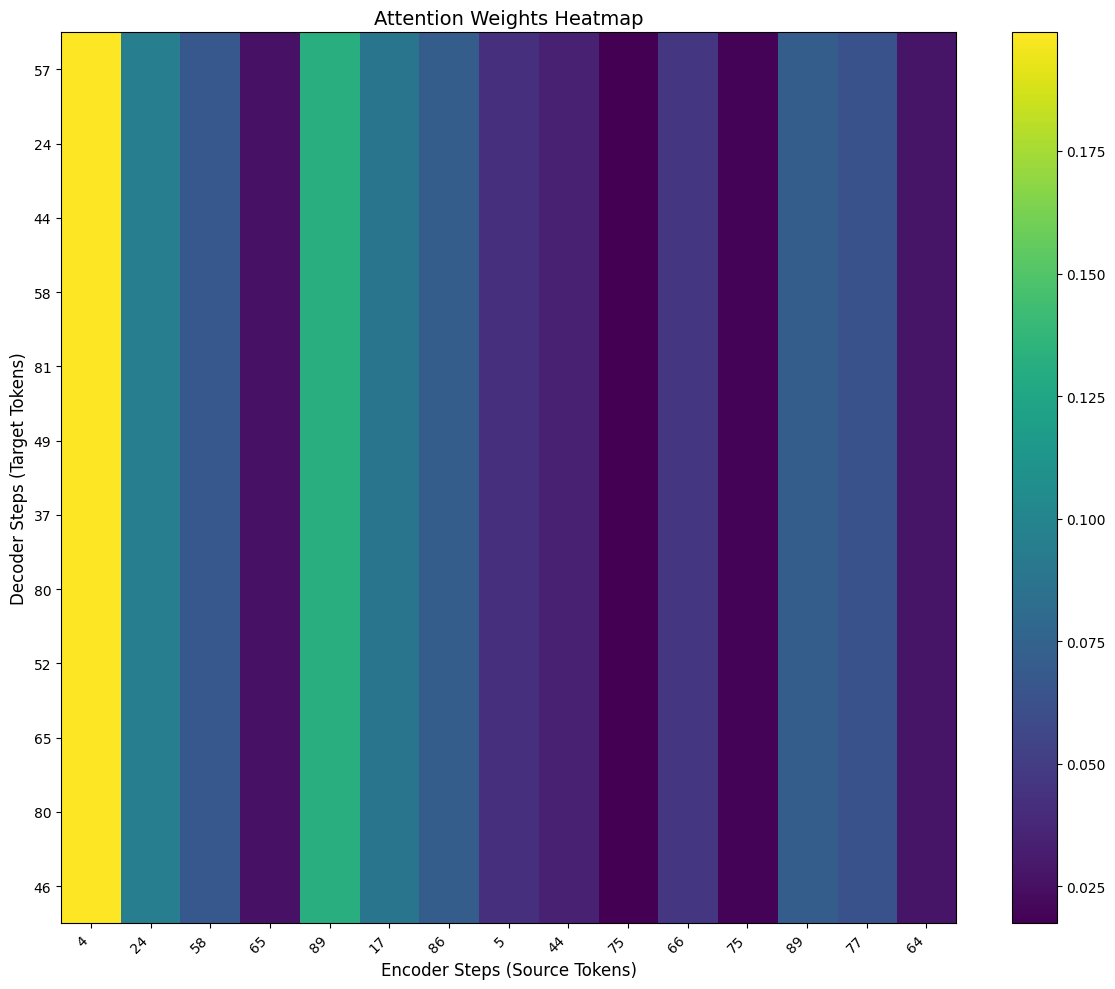

Attention matrix shape: (12, 15)


In [32]:
src_test = torch.randint(4, vocab_size, (15,))
tgt_test = torch.randint(4, vocab_size, (12,))

class DecoderWithAttentionWeights(DecoderWithAttention):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__(vocab_size, emb_size, hidden_size)
        self.attn_layer = AttentionLayerWithWeights(hidden_size, hidden_size)
    
    def forward_step(self, prev_token, enc_sequences, h, c):
        prev_emb = self.emb(prev_token)
        attn_applied, _ = self.attn_layer(enc_sequences, h.squeeze(0))
        lstm_input = torch.cat([prev_emb, attn_applied.unsqueeze(1)], dim=-1)
        output, (h, c) = self.lstm(lstm_input, (h, c))
        logits = self.fc_out(output.squeeze(1))
        return logits, h, c

encoder_viz = Encoder(vocab_size, emb_size, hidden_size).to(device)
decoder_viz = DecoderWithAttentionWeights(vocab_size, emb_size, hidden_size).to(device)

print("Visualizing attention...")
attention_weights = collect_and_plot(encoder_viz, decoder_viz, src_test, tgt_test)
print(f"Attention matrix shape: {attention_weights.shape}")